In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import xarray as xr
from glob import glob
import os
from netCDF4 import Dataset
import pandas as pd
from datetime import datetime, date, timedelta
from pathlib import Path
import scipy
import scipy.ndimage
from mpl_toolkits.axes_grid1 import ImageGrid
import math
import cc3d

from mpl_toolkits.axes_grid1 import make_axes_locatable

#constants
t = 6 # time index
target_idx = 7
z_min = 0
z_max = 200

#Input
input_dir = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/full-area/")
source_input_dir = Path("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/")

#variables

In [27]:
#load datasets
#ds_ql_mask = xr.open_dataset(input_dir / "ql_mask.nc", decode_times=False)
ds_cloud_mask = xr.open_dataset(input_dir / "cloud_mask.nc", decode_times=False)
ds_w_mask = xr.open_dataset(input_dir / "w_mask.nc", decode_times=False)
ds_shell_mask = xr.open_dataset(input_dir / "shell_mask.nc", decode_times=False)
ds_shell_labels = xr.open_dataset(input_dir / "shell_labels.nc", decode_times=False)
ds_cloud_labels = xr.open_dataset(input_dir / "cloud_labels.nc", decode_times=False)

ds_ql = xr.open_dataset(source_input_dir / "ql.nc", decode_times=False,chunks={'time': 1})
ds_w = xr.open_dataset(source_input_dir / "w.nc", decode_times=False,chunks={'time': 1})
ds_w = ds_w.rename({'zh':'z'}).interp(z=ds_ql.z)

In [28]:
w_z_slice = ds_w["w"].isel(time=t).sel(z=slice(z_min, z_max))
z_0_coverage_w = w_z_slice.min(dim='z').compute()
coverage_percentage_w = ((z_0_coverage_w < -0.25).sum().item() / z_0_coverage_w.size) * 100

In [29]:
shell_labels_slice_z_range = ds_shell_labels.isel(time=t).sel(z=slice(z_min, z_max))
shell_labels_slice = ds_shell_labels.isel(time=t)
cloud_labels_slice = ds_cloud_labels.isel(time=t)
shell_mask_slice = ds_shell_mask.isel(time=t).sel(z=slice(z_min, z_max))
w_mask_slice = ds_w_mask.isel(time=t).sel(z=slice(z_min, z_max))
z_0_coverage = shell_labels_slice_z_range.shell_labels.max(dim='z')
z_0_coverage_mask = shell_mask_slice.shell_mask.max(dim='z')
z_0_coverage_w_mask = w_mask_slice.w_mask.max(dim='z')
coverage_percentage = ((z_0_coverage > 0).sum().item() / z_0_coverage.size) * 100
coverage_percentage_mask = ((z_0_coverage_mask > 0).sum().item() / z_0_coverage_mask.size) * 100
coverage_percentage_w_mask = ((z_0_coverage_w_mask > 0).sum().item() / z_0_coverage_w_mask.size) * 100

In [30]:
coverage_percentage

0.8212089538574219

In [31]:
coverage_percentage_mask

0.8212089538574219

In [32]:
coverage_percentage_w

27.45523452758789

In [33]:
coverage_percentage_w_mask

5.263710021972656

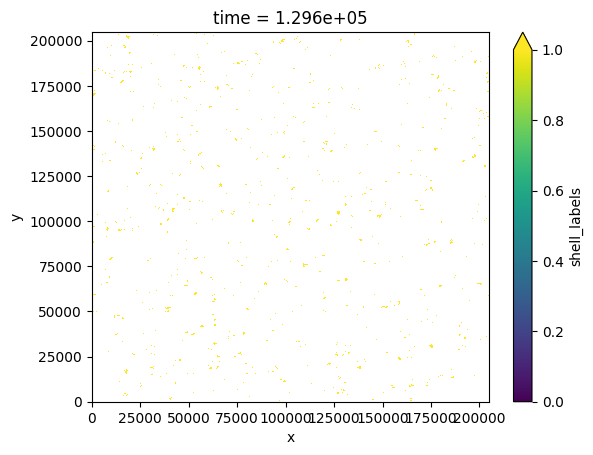

In [34]:
z_0_coverage.where(z_0_coverage > 0).plot(cmap='viridis', vmin=0, vmax=1)

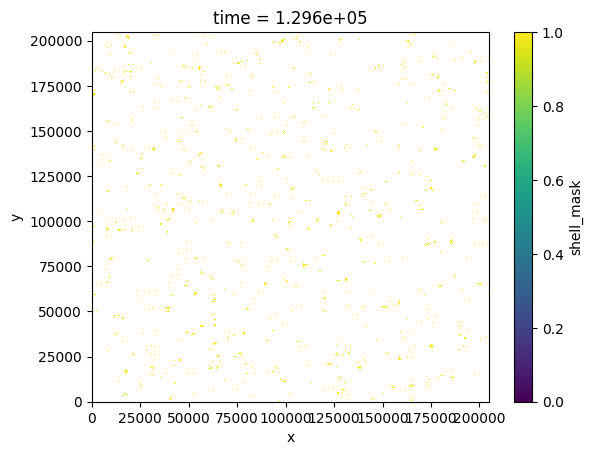

In [35]:
z_0_coverage_mask.where(z_0_coverage_mask > 0).plot(cmap='viridis', vmin=0, vmax=1)

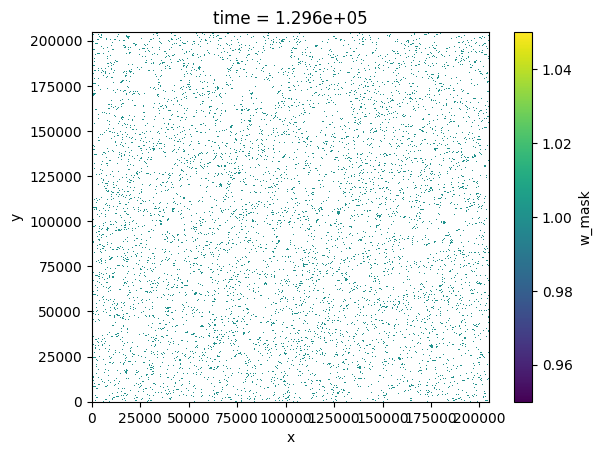

In [36]:
z_0_coverage_w_mask.where(z_0_coverage_w_mask > 0).plot(x="x", y="y", cmap="viridis")

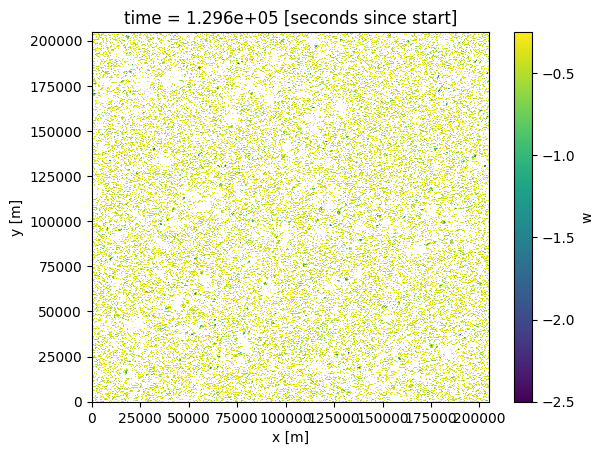

In [37]:
z_0_coverage_w.where(z_0_coverage_w < -0.25).plot(x="x", y="y", cmap="viridis")

In [38]:
shell_labels_slice_z_range = ds_shell_labels.isel(time=t).sel(z=slice(z_min, z_max))
low_shell_ids = np.unique(shell_labels_slice_z_range.shell_labels.where(shell_labels_slice_z_range.shell_labels > 0).values)

low_shell_ids

array([2.000e+00, 6.000e+00, 7.000e+00, 1.300e+01, 1.400e+01, 1.700e+01,
       1.900e+01, 2.000e+01, 2.600e+01, 3.200e+01, 3.600e+01, 3.800e+01,
       4.500e+01, 5.000e+01, 5.200e+01, 5.300e+01, 5.400e+01, 5.900e+01,
       6.100e+01, 6.200e+01, 6.800e+01, 7.300e+01, 7.700e+01, 7.800e+01,
       7.900e+01, 8.300e+01, 8.800e+01, 9.300e+01, 9.400e+01, 9.500e+01,
       1.040e+02, 1.050e+02, 1.080e+02, 1.090e+02, 1.110e+02, 1.130e+02,
       1.210e+02, 1.230e+02, 1.250e+02, 1.360e+02, 1.410e+02, 1.450e+02,
       1.460e+02, 1.590e+02, 1.700e+02, 1.730e+02, 1.750e+02, 1.780e+02,
       1.910e+02, 1.920e+02, 1.930e+02, 1.950e+02, 2.010e+02, 2.070e+02,
       2.080e+02, 2.100e+02, 2.110e+02, 2.130e+02, 2.140e+02, 2.230e+02,
       2.240e+02, 2.270e+02, 2.280e+02, 2.310e+02, 2.360e+02, 2.370e+02,
       2.380e+02, 2.400e+02, 2.420e+02, 2.430e+02, 2.510e+02, 2.570e+02,
       2.710e+02, 2.720e+02, 2.740e+02, 2.750e+02, 2.760e+02, 2.800e+02,
       2.860e+02, 2.990e+02, 3.030e+02, 3.060e+02, 

In [ ]:
all_shell_ids = np.unique(ds_shell_labels.shell_labels.where(ds_shell_labels.shell_labels > 0).isel(time=t).values)


In [53]:
len(low_shell_ids)

945

In [54]:
len(all_shell_ids)

4082

In [52]:
len(low_shell_ids) / len(all_shell_ids) * 100

23.150416462518372

🎉 Success! Found 213 valid shell voxels. Plotting now...


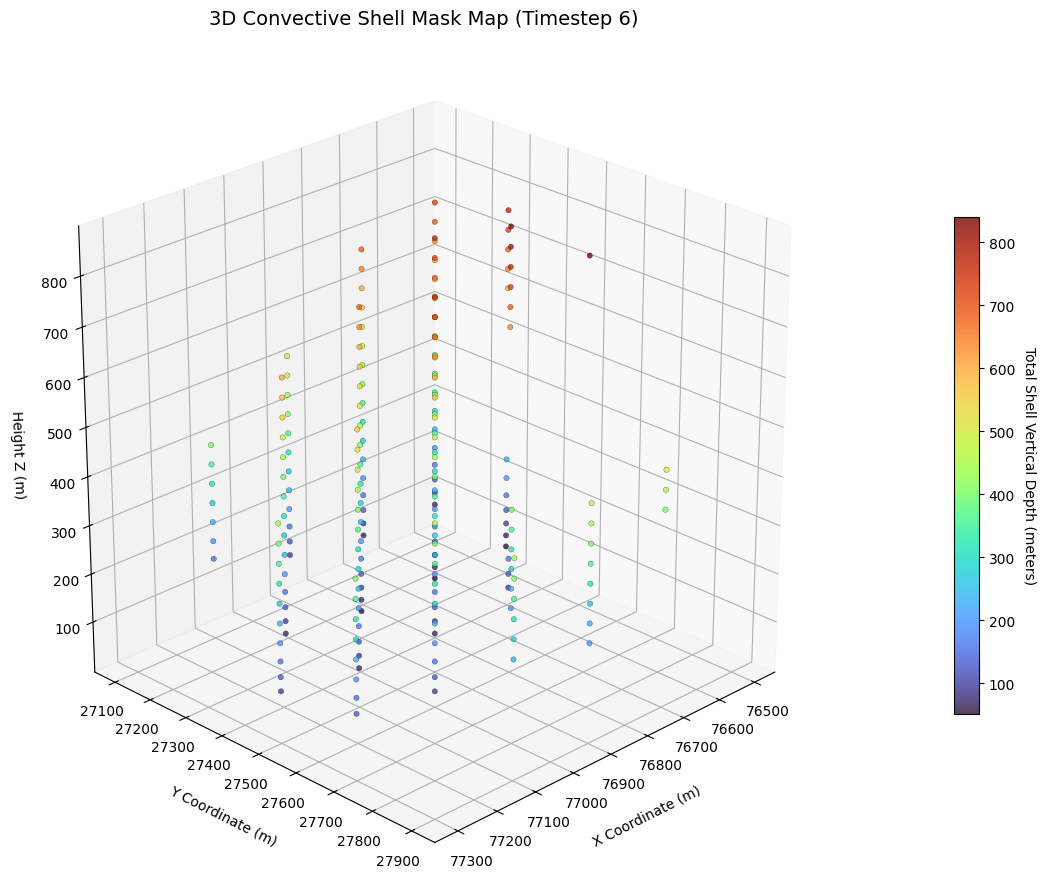

In [42]:

#3D plotting
time_idx = t

depth_3d_full_shell = ds_shell_mask["shell_mask"].where(ds_shell_mask["shell_mask"] != 0).values[time_idx, :, :, :]

#extract labels
labels_3d_slice = shell_labels_slice.shell_labels.values[:, :, :]

#apply labels
target_id = low_shell_ids[target_idx]
depth_3d_full_shell = np.where(labels_3d_slice == target_id, depth_3d_full_shell, np.nan)

valid_indices = np.argwhere(~np.isnan(depth_3d_full_shell))

# Print a diagnostic message to your console so you know exactly what's happening
if valid_indices.size == 0:
    print(f"⚠️ WARNING: No valid shell depth data found anywhere in the domain at timestep {time_idx}!")
    print("Double check that your cc3d loop ran completely and successfully populated 'shell_depth'.")
else:
    print(f"🎉 Success! Found {valid_indices.shape[0]} valid shell voxels. Plotting now...")

z_grid_values = ds_shell_mask.z.values
y_grid_values = ds_shell_mask.y.values
x_grid_values = ds_shell_mask.x.values

z_vals = z_grid_values[valid_indices[:, 0]]
y_vals = y_grid_values[valid_indices[:, 1]]
x_vals = x_grid_values[valid_indices[:, 2]]

depth_colors = depth_3d_full_shell[valid_indices[:, 0], valid_indices[:, 1], valid_indices[:, 2]]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    x_vals, 
    y_vals, 
    z_vals, 
    c=z_vals, 
    cmap="turbo", 
    s=15,                      # Slightly larger to fill gaps
    alpha=0.8,                 # High opacity so foreground shapes remain distinct
    depthshade=True,           # 🌟 FIX 2: Enable natural camera-distance shading
    edgecolor="black",         # 🌟 FIX 3: Add dark borders to distinguish overlapping voxels
    linewidth=0.2              # Keep the border hairline thin so it doesn't overpower the color
)

ax.set_xlabel("X Coordinate (m)", labelpad=10)
ax.set_ylabel("Y Coordinate (m)", labelpad=10)
ax.set_zlabel("Height Z (m)", labelpad=10)
ax.set_title(f"3D Convective Shell Mask Map (Timestep {time_idx})", fontsize=14, pad=20)

cb = fig.colorbar(sc, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cb.set_label("Total Shell Vertical Depth (meters)", rotation=270, labelpad=15)

# Tilt the view to get a great look at the depth columns
ax.view_init(elev=25, azim=45)
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()


🎉 Success! Found 28 valid shell voxels. Plotting now...


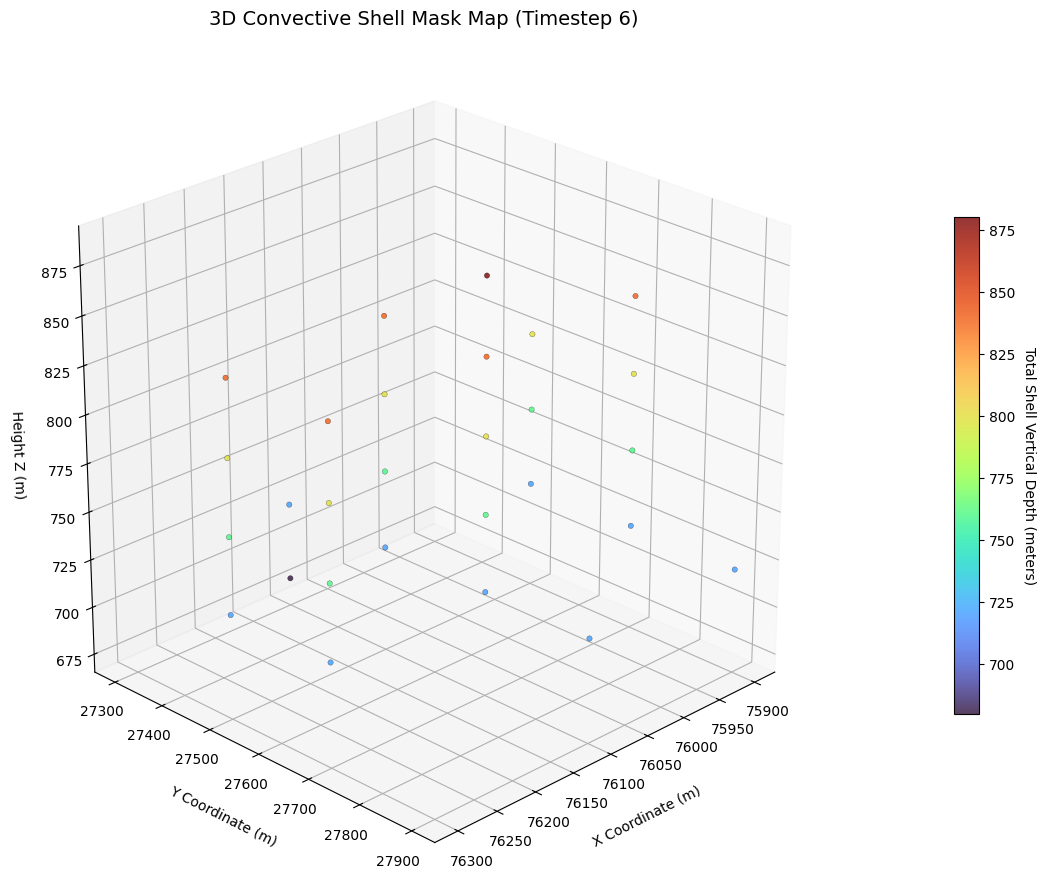

In [43]:

#3D plotting
time_idx = t

depth_3d_full_cloud = ds_cloud_mask["cloud_mask"].where(ds_cloud_mask["cloud_mask"] != 0).values[time_idx, :, :, :]
#extract labels
labels_3d_slice = cloud_labels_slice.cloud_labels.values[:, :, :]

#apply labels
target_id = low_shell_ids[target_idx]
depth_3d_full_cloud = np.where(labels_3d_slice == target_id, depth_3d_full_cloud, np.nan)

valid_indices = np.argwhere(~np.isnan(depth_3d_full_cloud))

# Print a diagnostic message to your console so you know exactly what's happening
if valid_indices.size == 0:
    print(f"⚠️ WARNING: No valid shell depth data found anywhere in the domain at timestep {time_idx}!")
    print("Double check that your cc3d loop ran completely and successfully populated 'shell_depth'.")
else:
    print(f"🎉 Success! Found {valid_indices.shape[0]} valid shell voxels. Plotting now...")

z_grid_values = ds_shell_mask.z.values
y_grid_values = ds_shell_mask.y.values
x_grid_values = ds_shell_mask.x.values

z_vals = z_grid_values[valid_indices[:, 0]]
y_vals = y_grid_values[valid_indices[:, 1]]
x_vals = x_grid_values[valid_indices[:, 2]]

depth_colors = depth_3d_full_cloud[valid_indices[:, 0], valid_indices[:, 1], valid_indices[:, 2]]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    x_vals, 
    y_vals, 
    z_vals, 
    c=z_vals, 
    cmap="turbo", 
    s=15,                      # Slightly larger to fill gaps
    alpha=0.8,                 # High opacity so foreground shapes remain distinct
    depthshade=True,           # 🌟 FIX 2: Enable natural camera-distance shading
    edgecolor="black",         # 🌟 FIX 3: Add dark borders to distinguish overlapping voxels
    linewidth=0.2              # Keep the border hairline thin so it doesn't overpower the color
)

ax.set_xlabel("X Coordinate (m)", labelpad=10)
ax.set_ylabel("Y Coordinate (m)", labelpad=10)
ax.set_zlabel("Height Z (m)", labelpad=10)
ax.set_title(f"3D Convective Shell Mask Map (Timestep {time_idx})", fontsize=14, pad=20)

cb = fig.colorbar(sc, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cb.set_label("Total Shell Vertical Depth (meters)", rotation=270, labelpad=15)

# Tilt the view to get a great look at the depth columns
ax.view_init(elev=25, azim=45)
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()


In [44]:
#establish vars
is_shell = ~np.isnan(depth_3d_full_shell)
is_cloud = ~np.isnan(depth_3d_full_cloud)
merged_np = is_shell | is_cloud
w_slice = ds_w["w"].isel(time=t).compute()
merged_3d = xr.DataArray(merged_np, coords=w_slice.coords, dims=w_slice.dims)
is_shell_3d = xr.DataArray(is_shell, coords=w_slice.coords, dims=w_slice.dims)
is_cloud_3d = xr.DataArray(is_cloud, coords=w_slice.coords, dims=w_slice.dims)

In [45]:
#is there any misplaced w
masked_w = w_slice.where(is_shell_3d, drop=True)
wrong_w = masked_w.where(masked_w >= -0.25, drop=True)
len(wrong_w)

0

In [46]:
#is the cloud and shell connected (no wrapping; ignoring ql dilation)

#label
labeled_array, num_features = scipy.ndimage.label(merged_np)


if num_features == 0:
    print("❌ The mask is completely empty.")
elif num_features == 1:
    print("✅ Success! The mask is fully connected (all one label).")
else:
    print(f"⚠️ The mask is fragmented into {num_features} separate pieces.")
    
    # Optional: Find out how large each fragmented piece is
    unique_labels, counts = np.unique(labeled_array, return_counts=True)
    # Ignore background (label 0)
    unique_labels = unique_labels[1:]
    counts = counts[1:]
    
    print(f"Largest component size: {counts.max()} grid cells")
    print(f"Smallest component size: {counts.min()} grid cells")

⚠️ The mask is fragmented into 2 separate pieces.
Largest component size: 213 grid cells
Smallest component size: 28 grid cells


In [47]:
#is the cloud and shell connected (ignoring ql dilation)

#label
padded_merged_np = np.pad(merged_np, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=0)
padded_labeled_array = cc3d.connected_components(
    padded_merged_np, 
    connectivity=6, 
    periodic_boundary=True
)
labeled_array = padded_labeled_array[1:-1, :, :].astype(np.uint32)

num_features = int(labeled_array.max())


if num_features == 0:
    print("❌ The mask is completely empty.")
elif num_features == 1:
    print("✅ Success! The mask is fully connected (all one label).")
else:
    print(f"⚠️ The mask is fragmented into {num_features} separate pieces.")
    
    # Optional: Find out how large each fragmented piece is
    unique_labels, counts = np.unique(labeled_array, return_counts=True)
    # Ignore background (label 0)
    unique_labels = unique_labels[1:]
    counts = counts[1:]
    
    print(f"Largest component size: {counts.max()} grid cells")
    print(f"Smallest component size: {counts.min()} grid cells")

⚠️ The mask is fragmented into 2 separate pieces.
Largest component size: 213 grid cells
Smallest component size: 28 grid cells


In [48]:
#is the cloud and shell connected (factoring in ql dilation)

expansion = np.zeros((3,3,3), dtype=bool)
expansion[1, 1, :] = True  # X axis
expansion[1, :, 1] = True  # Y axis
expansion[:, 1, 1] = True  # Z axis


padded_seed = np.pad(is_cloud, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=0)
padded_seed = np.pad(padded_seed, ((0, 0), (1, 1), (1, 1)), mode='wrap')
padded_seed = scipy.ndimage.binary_dilation(padded_seed, structure=expansion, iterations=1)
padded_seed = padded_seed[1:-1, 1:-1, 1:-1]

merged_with_dilation = is_shell | padded_seed

#label
padded_merged_np = np.pad(merged_with_dilation, ((1, 1), (0, 0), (0, 0)), mode='constant', constant_values=0)
padded_labeled_array = cc3d.connected_components(
    padded_merged_np, 
    connectivity=6, 
    periodic_boundary=True
)
labeled_array = padded_labeled_array[1:-1, :, :].astype(np.uint32)

num_features = int(labeled_array.max())


if num_features == 0:
    print("❌ The mask is completely empty.")
elif num_features == 1:
    print("✅ Success! The mask is fully connected (all one label).")
else:
    print(f"⚠️ The mask is fragmented into {num_features} separate pieces.")
    
    # Optional: Find out how large each fragmented piece is
    unique_labels, counts = np.unique(labeled_array, return_counts=True)
    # Ignore background (label 0)
    unique_labels = unique_labels[1:]
    counts = counts[1:]
    
    print(f"Largest component size: {counts.max()} grid cells")
    print(f"Smallest component size: {counts.min()} grid cells")

✅ Success! The mask is fully connected (all one label).


In [49]:
len(is_cloud[is_cloud == True])

28

In [50]:
z_idx_ql, y_idx_ql, x_idx_ql = np.where(is_cloud)
cloud_z_coords = z_grid_values[z_idx_ql]
cloud_y_coords = y_grid_values[y_idx_ql]
cloud_x_coords = x_grid_values[x_idx_ql]
ql_time_slice = ds_ql["ql"].isel(time=t)
cloud_ql_values = ql_time_slice.values[z_idx_ql, y_idx_ql, x_idx_ql]

for i in range(len(cloud_z_coords)):
    print(f"Cloud voxel {i}: Z={cloud_z_coords[i]}, Y={cloud_y_coords[i]}, X={cloud_x_coords[i]}, QL={cloud_ql_values[i]}")


Cloud voxel 0: Z=680.0, Y=27300.0, X=76100.0, QL=1.7210841178894043e-05
Cloud voxel 1: Z=720.0, Y=27300.0, X=76100.0, QL=1.8533319234848022e-05
Cloud voxel 2: Z=720.0, Y=27500.0, X=75900.0, QL=2.2320076823234558e-05
Cloud voxel 3: Z=720.0, Y=27500.0, X=76100.0, QL=6.674695760011673e-05
Cloud voxel 4: Z=720.0, Y=27500.0, X=76300.0, QL=4.700198769569397e-05
Cloud voxel 5: Z=720.0, Y=27700.0, X=75900.0, QL=2.692360430955887e-05
Cloud voxel 6: Z=720.0, Y=27700.0, X=76100.0, QL=5.043763667345047e-05
Cloud voxel 7: Z=720.0, Y=27700.0, X=76300.0, QL=3.519188612699509e-05
Cloud voxel 8: Z=720.0, Y=27900.0, X=75900.0, QL=5.64083456993103e-05
Cloud voxel 9: Z=720.0, Y=27900.0, X=76100.0, QL=5.837250500917435e-05
Cloud voxel 10: Z=760.0, Y=27500.0, X=75900.0, QL=0.00010559428483247757
Cloud voxel 11: Z=760.0, Y=27500.0, X=76100.0, QL=0.00018267612904310226
Cloud voxel 12: Z=760.0, Y=27500.0, X=76300.0, QL=0.00015058275312185287
Cloud voxel 13: Z=760.0, Y=27700.0, X=75900.0, QL=0.00010316073894500